# RFM Customer Segmentation

This notebook loads raw transaction data, calculates RFM (Recency, Frequency, Monetary) metrics per client, scales the data, finds the optimal number of clusters, applies K-Means clustering, and labels each cluster into one of 4 business segments: **Champions**, **Réguliers**, **À Surveiller**, **Perdus**.

All files are read from and written to the same folder as this notebook (no subfolders).

## 1. Import libraries

In [1]:
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

## 2. Load raw transaction data and check quality

In [2]:
df = pd.read_csv('RFM_unified_data.csv')  # Load the raw transaction-level file
df['DateVente'] = pd.to_datetime(df['DateVente'])  # Convert the sale date to datetime

print(f'Rows loaded: {len(df)}')
print(f'Unique clients: {df["ClientID"].nunique()}')

key_columns = ['ClientID', 'DateVente', 'MontantFinal']  # Columns required to compute RFM
print('Missing values in key columns:')
print(df[key_columns].isnull().sum())
print(f'Exact duplicate rows: {df.duplicated().sum()}')

df = df.dropna(subset=key_columns).drop_duplicates()  # Clean on the essential columns only
print(f'Rows after cleaning: {len(df)}')

Rows loaded: 25000
Unique clients: 4938
Missing values in key columns:
ClientID        0
DateVente       0
MontantFinal    0
dtype: int64
Exact duplicate rows: 0
Rows after cleaning: 25000


## 3. Calculate Recency, Frequency, Monetary per client

The reference date is set to the day after the most recent sale in the dataset.
- **Recency**: days since the client's last purchase.
- **Frequency**: total number of transactions for the client.
- **Monetary**: sum of `MontantFinal` across all the client's transactions.

In [3]:
reference_date = df['DateVente'].max() + pd.Timedelta(days=1)  # Day after the last observed sale
print(f'Reference date used for Recency: {reference_date.date()}')

rfm = df.groupby('ClientID').agg(
    Recency=('DateVente', lambda x: (reference_date - x.max()).days),
    Frequency=('TransactionID', 'count'),
    Monetary=('MontantFinal', 'sum')
).reset_index()  # Aggregate transactions per client into R, F, M

print(f'RFM table built for {len(rfm)} clients.')
print(rfm[['Recency', 'Frequency', 'Monetary']].describe())

negative_count = (rfm[['Recency', 'Frequency', 'Monetary']] < 0).sum().sum()  # Sanity check for negative values
print('No negative RFM values detected.' if negative_count == 0 else f'WARNING: {negative_count} negative RFM values found.')

Reference date used for Recency: 2026-01-01


RFM table built for 4938 clients.
           Recency    Frequency       Monetary
count  4938.000000  4938.000000    4938.000000
mean    243.809235     5.062778   51017.471156
std     224.959459     2.368714   57861.122955
min       1.000000     1.000000     799.500000
25%      76.000000     3.000000   15313.360750
50%     177.000000     5.000000   31117.404500
75%     347.000000     7.000000   62987.850750
max    1417.000000    16.000000  490681.006000
No negative RFM values detected.


## 4. Scale the RFM features

In [4]:
rfm_columns = ['Recency', 'Frequency', 'Monetary']  # Columns to standardize
X = rfm[rfm_columns]  # Extract the RFM feature matrix
scaler = StandardScaler()  # Initialize the scaler
X_scaled = scaler.fit_transform(X)  # Fit and transform the features
X_scaled_df = pd.DataFrame(X_scaled, columns=rfm_columns)  # Rebuild a dataframe with the same column names

print('Means after scaling (expected close to 0):')
print(X_scaled_df.mean())
print('\nStandard deviations after scaling (expected close to 1):')
print(X_scaled_df.std(ddof=0))

Means after scaling (expected close to 0):
Recency     -3.165642e-17
Frequency    1.539653e-16
Monetary     9.568872e-17
dtype: float64

Standard deviations after scaling (expected close to 1):
Recency      1.0
Frequency    1.0
Monetary     1.0
dtype: float64


## 5. Plot distributions before and after scaling

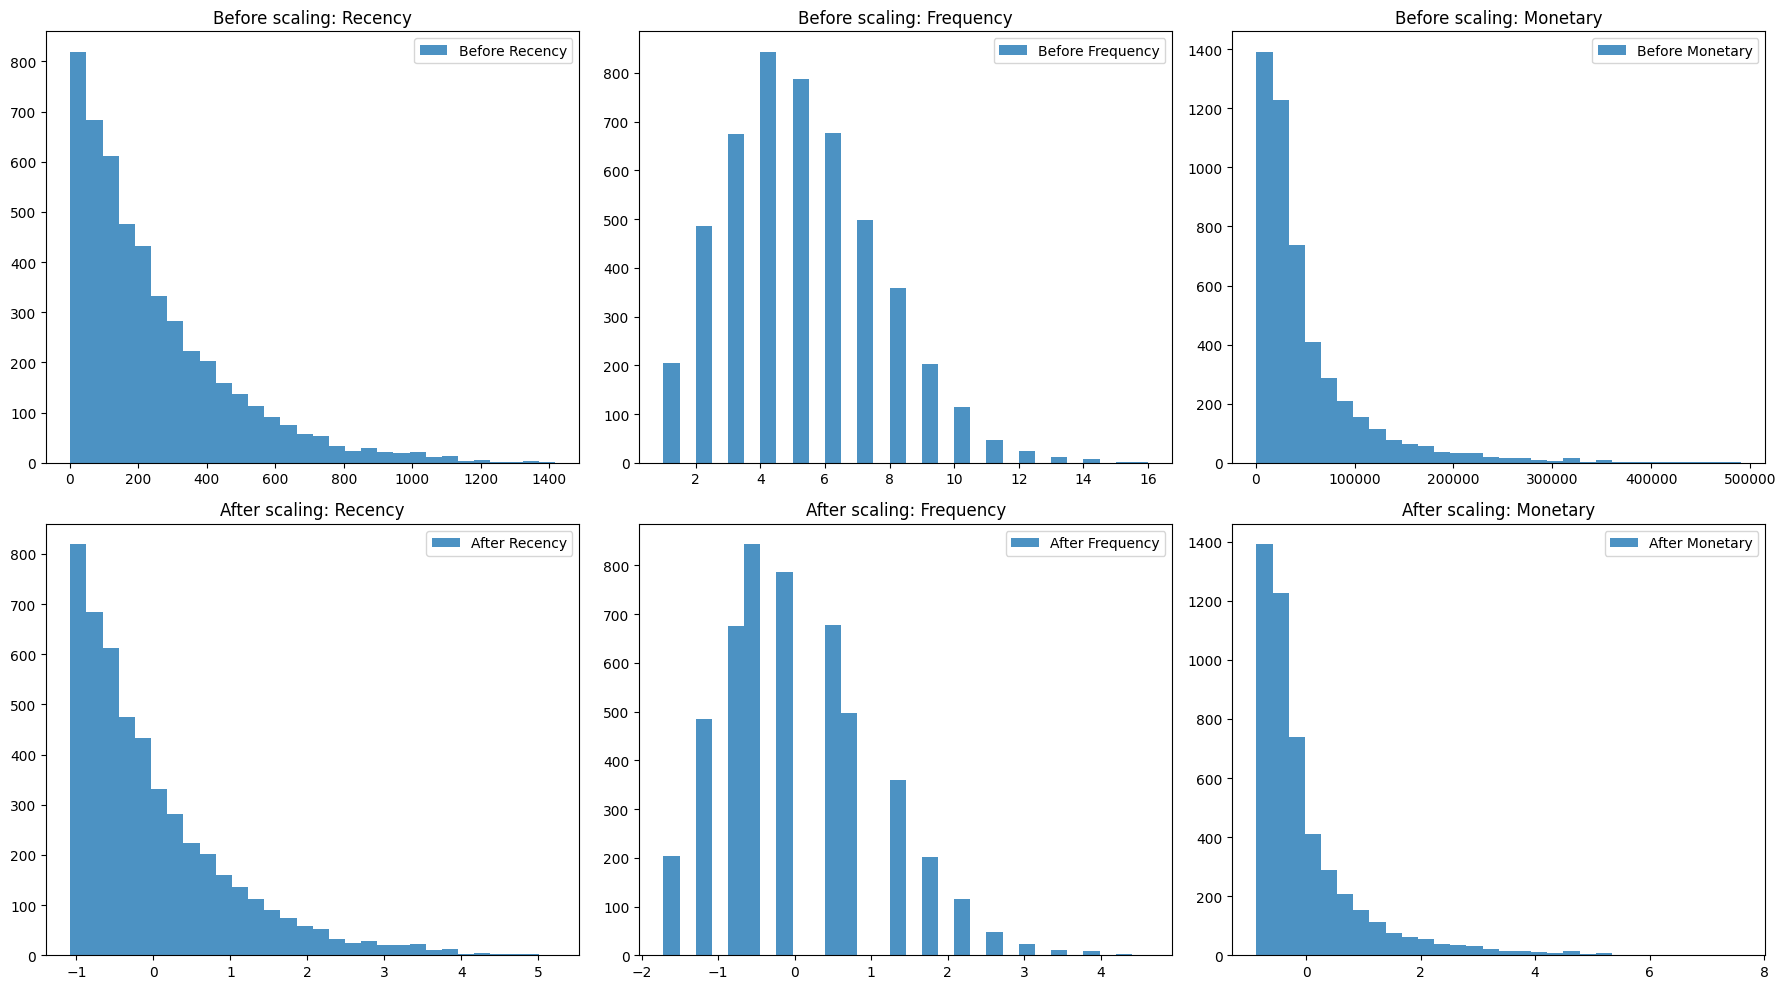

Saved: distributions.png


In [5]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))  # Create a 2x3 grid
for idx, col in enumerate(rfm_columns):  # Loop through each RFM feature
    axes[0, idx].hist(rfm[col], bins=30, alpha=0.8, label=f'Before {col}')  # Raw distribution
    axes[0, idx].set_title(f'Before scaling: {col}')
    axes[0, idx].legend()
    axes[1, idx].hist(X_scaled_df[col], bins=30, alpha=0.8, label=f'After {col}')  # Scaled distribution
    axes[1, idx].set_title(f'After scaling: {col}')
    axes[1, idx].legend()
plt.tight_layout()
plt.savefig('distributions.png', dpi=300)  # Save directly in the current folder
plt.show()
print('Saved: distributions.png')

## 6. Find the optimal number of clusters (K)

Evaluate K from 2 to 10 using inertia and silhouette score.

In [6]:
inertias = []
silhouette_scores = []
K_range = range(2, 11)

for k in K_range:
    kmeans_test = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    kmeans_test.fit(X_scaled_df)
    inertias.append(kmeans_test.inertia_)
    sil_score = silhouette_score(X_scaled_df, kmeans_test.labels_)
    silhouette_scores.append(sil_score)
    print(f'K={k}: Inertia={kmeans_test.inertia_:.2f}, Silhouette={sil_score:.4f}')

optimal_k_stat = list(K_range)[int(np.argmax(silhouette_scores))]  # Best K by silhouette (statistical reference)
print(f'\nBest K by silhouette score (statistical): {optimal_k_stat}')

K=2: Inertia=10036.81, Silhouette=0.3110


K=3: Inertia=7254.20, Silhouette=0.3410


K=4: Inertia=5318.05, Silhouette=0.3343


K=5: Inertia=4661.99, Silhouette=0.3382


K=6: Inertia=4041.21, Silhouette=0.3145


K=7: Inertia=3522.40, Silhouette=0.2946


K=8: Inertia=3163.65, Silhouette=0.2966


K=9: Inertia=2902.72, Silhouette=0.3012


K=10: Inertia=2708.55, Silhouette=0.2773

Best K by silhouette score (statistical): 3


## 7. Plot elbow and silhouette curves

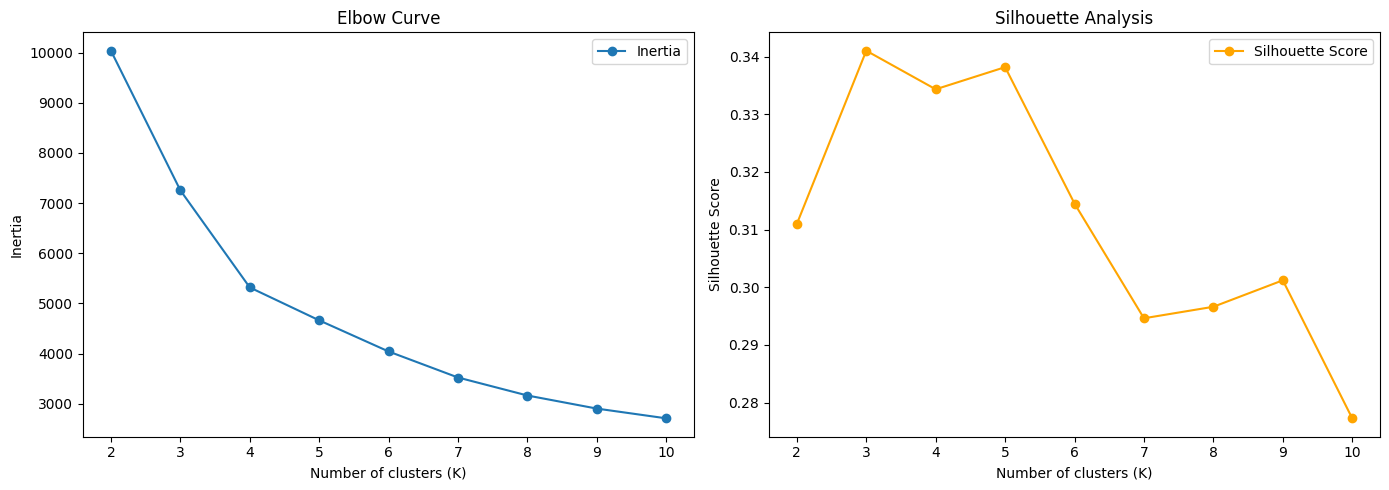

Saved: elbow_silhouette_analysis.png


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(list(K_range), inertias, marker='o', label='Inertia')
axes[0].set_title('Elbow Curve')
axes[0].set_xlabel('Number of clusters (K)')
axes[0].set_ylabel('Inertia')
axes[0].legend()
axes[1].plot(list(K_range), silhouette_scores, marker='o', color='orange', label='Silhouette Score')
axes[1].set_title('Silhouette Analysis')
axes[1].set_xlabel('Number of clusters (K)')
axes[1].set_ylabel('Silhouette Score')
axes[1].legend()
plt.tight_layout()
plt.savefig('elbow_silhouette_analysis.png', dpi=300)
plt.show()
print('Saved: elbow_silhouette_analysis.png')

## 8. Train the final K-Means model (K=4)

K is fixed to 4 to match the 4 requested business segments: Champions, Réguliers, À Surveiller, Perdus.

In [8]:
K = 4  # Fixed number of clusters to match the 4 business segments
kmeans = KMeans(n_clusters=K, init='k-means++', random_state=42, n_init=10)  # Initialize the final model
rfm['cluster'] = kmeans.fit_predict(X_scaled_df)  # Train and assign cluster labels
print('Client count per cluster:')
print(rfm['cluster'].value_counts().sort_index())

Client count per cluster:
cluster
0    2010
1     440
2    1575
3     913
Name: count, dtype: int64


## 9. Profile clusters and assign business segments

Each cluster is ranked on Recency (lower = better), Frequency (higher = better) and Monetary (higher = better). The combined rank score orders clusters from best to worst.

In [9]:
cluster_summary = rfm.groupby('cluster')[['Recency', 'Frequency', 'Monetary']].mean()  # Average profile per cluster
print(cluster_summary)

rec_rank = cluster_summary['Recency'].rank(ascending=True, method='min')  # 1 = most recent
freq_rank = cluster_summary['Frequency'].rank(ascending=False, method='min')  # 1 = most frequent
mon_rank = cluster_summary['Monetary'].rank(ascending=False, method='min')  # 1 = highest spender
combined_score = rec_rank + freq_rank + mon_rank  # Lower total = better customer profile
ordered_clusters = combined_score.sort_values().index.tolist()  # Sort clusters from best to worst
print('\nCombined score per cluster (lower = better):')
print(combined_score.sort_values())

segment_names = ['Champions', 'Réguliers', 'À Surveiller', 'Perdus']  # Business order from best to worst
cluster_labels = {int(cid): segment_names[i] for i, cid in enumerate(ordered_clusters)}  # Map cluster -> segment
print('\nCluster -> segment mapping:')
print(cluster_labels)

rfm['SegmentRFM'] = rfm['cluster'].map(cluster_labels)  # Add the final segment column

            Recency  Frequency       Monetary
cluster                                      
0        165.030348   3.636816   30128.596174
1        162.861364   7.145455  199213.968745
2        147.934603   7.336508   49412.502488
3        621.646221   3.276013   28353.731209

Combined score per cluster (lower = better):
cluster
2     4.0
1     5.0
0     9.0
3    12.0
dtype: float64

Cluster -> segment mapping:
{2: 'Champions', 1: 'Réguliers', 0: 'À Surveiller', 3: 'Perdus'}


## 10. Add recommended actions per segment

In [10]:
action_map = {  # Recommended action per segment
    'Champions': 'VIP program, exclusive rewards, cross-selling',
    'Réguliers': 'Loyalty offers, bonus points, upselling',
    'À Surveiller': 'Light follow-up, personalized offer, satisfaction survey',
    'Perdus': 'Reactivation campaign, special win-back offer'
}
rfm['ActionRecommandee'] = rfm['SegmentRFM'].map(action_map)  # Add the recommended action column

print(rfm['SegmentRFM'].value_counts())
print('\nAverage RFM profile per segment:')
print(rfm.groupby('SegmentRFM')[['Recency', 'Frequency', 'Monetary']].mean().round(1))

SegmentRFM
À Surveiller    2010
Champions       1575
Perdus           913
Réguliers        440
Name: count, dtype: int64

Average RFM profile per segment:
              Recency  Frequency  Monetary
SegmentRFM                                
Champions       147.9        7.3   49412.5
Perdus          621.6        3.3   28353.7
Réguliers       162.9        7.1  199214.0
À Surveiller    165.0        3.6   30128.6


## 11. Visualize segments with PCA

PC1 explained variance: 0.5415
PC2 explained variance: 0.2818
Total explained variance: 0.8232


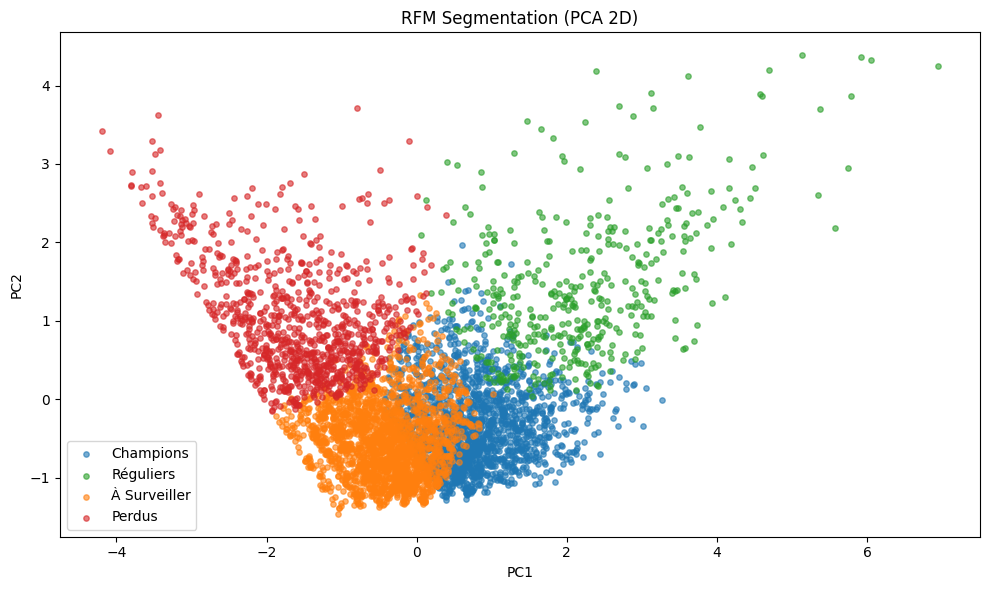

Saved: pca_segments.png


In [11]:
pca = PCA(n_components=2)  # Reduce to 2 components for visualization
X_pca = pca.fit_transform(X_scaled_df)
print(f'PC1 explained variance: {pca.explained_variance_ratio_[0]:.4f}')
print(f'PC2 explained variance: {pca.explained_variance_ratio_[1]:.4f}')
print(f'Total explained variance: {pca.explained_variance_ratio_.sum():.4f}')

pca_df = pd.DataFrame({'PC1': X_pca[:, 0], 'PC2': X_pca[:, 1], 'SegmentRFM': rfm['SegmentRFM']})

segment_colors = {  # Fixed color per segment for consistent reading
    'Champions': '#1f77b4',
    'Réguliers': '#2ca02c',
    'À Surveiller': '#ff7f0e',
    'Perdus': '#d62728'
}
plt.figure(figsize=(10, 6))
for seg in ['Champions', 'Réguliers', 'À Surveiller', 'Perdus']:
    temp = pca_df[pca_df['SegmentRFM'] == seg]
    plt.scatter(temp['PC1'], temp['PC2'], alpha=0.6, label=seg, color=segment_colors[seg], s=15)
plt.title('RFM Segmentation (PCA 2D)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend()
plt.tight_layout()
plt.savefig('pca_segments.png', dpi=300)
plt.show()
print('Saved: pca_segments.png')

## 12. Save all outputs

Everything is saved directly in the current folder: the scaler, the K-Means model, the optimal-K analysis table, and the final segmented dataset.

In [12]:
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)  # Save the fitted scaler

with open('kmeans_model.pkl', 'wb') as f:
    pickle.dump(kmeans, f)  # Save the trained K-Means model

analysis_df = pd.DataFrame({'K': list(K_range), 'Inertia': inertias, 'Silhouette_Score': silhouette_scores})
analysis_df.to_csv('optimal_k_analysis.csv', index=False)  # Save the K evaluation table

rfm.to_csv('rfm_with_clusters.csv', index=False)  # Save the final segmented dataset

print('Saved: scaler.pkl')
print('Saved: kmeans_model.pkl')
print('Saved: optimal_k_analysis.csv')
print('Saved: rfm_with_clusters.csv')

Saved: scaler.pkl
Saved: kmeans_model.pkl
Saved: optimal_k_analysis.csv
Saved: rfm_with_clusters.csv
